# Financial Distress Prediction Using Machine Learning

## Machine Learning for Business Applications

### MBA – Business Analytics

## 1. Business Problem

Financial institutions and investors need to identify companies that may be experiencing financial distress at an early stage. Early identification of financially distressed companies can support better financial risk assessment and decision-making.

### Analytics Objective

Develop a machine learning classification model that predicts whether a company is financially healthy or financially distressed based on its available financial and non-financial characteristics.

### Target Variable

Financial Distress

### Business Decision

The prediction can be used as an early-warning indicator to identify companies requiring additional financial analysis, monitoring, credit review, or investment due diligence.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [38]:
df = pd.read_csv("/Users/aakash/Documents/MLBA Assignment/Financial Distress Project/Data/Financial Distress.csv")

In [39]:
df.head()

,Company,Time,Financial Distress,x1,x2,x3,x4,x5,x6,x7,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1,1,0.010636,1.2810,0.022934,0.87454,1.21640,0.060940,0.188270,0.52510,...,85.437,27.07,26.102,16.000,16.0,0.2,22,0.060390,30,49
1,1,2,-0.455970,1.2700,0.006454,0.82067,1.00490,-0.014080,0.181040,0.62288,...,107.090,31.31,30.194,17.000,16.0,0.4,22,0.010636,31,50
2,1,3,-0.325390,1.0529,-0.059379,0.92242,0.72926,0.020476,0.044865,0.43292,...,120.870,36.07,35.273,17.000,15.0,-0.2,22,-0.455970,32,51
3,1,4,-0.566570,1.1131,-0.015229,0.85888,0.80974,0.076037,0.091033,0.67546,...,54.806,39.80,38.377,17.167,16.0,5.6,22,-0.325390,33,52
4,2,1,1.357300,1.0623,0.107020,0.81460,0.83593,0.199960,0.047800,0.74200,...,85.437,27.07,26.102,16.000,16.0,0.2,29,1.251000,7,27


In [40]:
df.shape

(3672, 86)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 86 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company             3672 non-null   int64  
 1   Time                3672 non-null   int64  
 2   Financial Distress  3672 non-null   float64
 3   x1                  3672 non-null   float64
 4   x2                  3672 non-null   float64
 5   x3                  3672 non-null   float64
 6   x4                  3672 non-null   float64
 7   x5                  3672 non-null   float64
 8   x6                  3672 non-null   float64
 9   x7                  3672 non-null   float64
 10  x8                  3672 non-null   float64
 11  x9                  3672 non-null   float64
 12  x10                 3672 non-null   float64
 13  x11                 3672 non-null   float64
 14  x12                 3672 non-null   float64
 15  x13                 3672 non-null   float64
 16  x14              

In [42]:
df.describe()

,Company,Time,Financial Distress,x1,x2,x3,x4,x5,x6,x7,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
count,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3.672000e+03,3672.000000,3672.000000,3672.000000,...,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000
mean,182.084423,7.528322,1.040257,1.387820,0.129706,0.615769,8.681599e-01,0.154949,0.106717,0.784031,...,86.839822,91.920506,89.115908,17.780855,15.198708,-2.664305,19.714597,1.100488,13.122277,33.044935
std,117.024636,4.064016,2.652227,1.452926,0.120013,0.177904,5.719519e-01,0.124904,0.210555,1.033606,...,16.706209,64.656504,64.349382,2.040152,2.828648,8.192663,7.508588,2.666733,9.465907,13.714563
min,1.000000,1.000000,-8.631700,0.075170,-0.258080,0.016135,5.350000e-07,-0.269790,-0.627750,0.035160,...,54.806000,24.318000,23.776000,15.250000,12.000000,-20.200000,1.000000,-0.499220,1.000000,2.000000
25%,80.000000,4.000000,0.172275,0.952145,0.048701,0.501888,5.525575e-01,0.070001,-0.027754,0.436003,...,79.951000,39.800000,38.377000,16.000000,13.000000,-7.000000,14.000000,0.189912,6.000000,21.000000
50%,168.000000,7.000000,0.583805,1.183600,0.107530,0.638690,7.752450e-01,0.131830,0.104325,0.641875,...,90.000000,66.120000,59.471000,17.000000,14.500000,0.200000,20.000000,0.594765,11.000000,34.000000
75%,264.250000,11.000000,1.351750,1.506475,0.188685,0.749425,1.039000e+00,0.219570,0.231230,0.896772,...,93.883000,130.500000,132.400000,20.000000,16.000000,2.100000,26.000000,1.355050,17.000000,44.000000
max,422.000000,14.000000,128.400000,51.954000,0.749410,0.967900,6.835600e+00,0.858540,0.929550,38.836000,...,120.870000,227.500000,214.500000,22.000000,22.000000,8.600000,37.000000,128.400000,49.000000,74.000000


In [43]:
df.columns.tolist()

['Company',
 'Time',
 'Financial Distress',
 'x1',
 'x2',
 'x3',
 'x4',
 'x5',
 'x6',
 'x7',
 'x8',
 'x9',
 'x10',
 'x11',
 'x12',
 'x13',
 'x14',
 'x15',
 'x16',
 'x17',
 'x18',
 'x19',
 'x20',
 'x21',
 'x22',
 'x23',
 'x24',
 'x25',
 'x26',
 'x27',
 'x28',
 'x29',
 'x30',
 'x31',
 'x32',
 'x33',
 'x34',
 'x35',
 'x36',
 'x37',
 'x38',
 'x39',
 'x40',
 'x41',
 'x42',
 'x43',
 'x44',
 'x45',
 'x46',
 'x47',
 'x48',
 'x49',
 'x50',
 'x51',
 'x52',
 'x53',
 'x54',
 'x55',
 'x56',
 'x57',
 'x58',
 'x59',
 'x60',
 'x61',
 'x62',
 'x63',
 'x64',
 'x65',
 'x66',
 'x67',
 'x68',
 'x69',
 'x70',
 'x71',
 'x72',
 'x73',
 'x74',
 'x75',
 'x76',
 'x77',
 'x78',
 'x79',
 'x80',
 'x81',
 'x82',
 'x83']

In [44]:
df.isnull().sum()

Company               0
Time                  0
Financial Distress    0
x1                    0
x2                    0
                     ..
x79                   0
x80                   0
x81                   0
x82                   0
x83                   0
Length: 86, dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.dtypes

Company                 int64
Time                    int64
Financial Distress    float64
x1                    float64
x2                    float64
                       ...   
x79                   float64
x80                     int64
x81                   float64
x82                     int64
x83                     int64
Length: 86, dtype: object

In [47]:
df["x80"].value_counts(dropna=False)

x80
15    382
25    371
29    360
9     335
26    274
18    245
14    236
19    169
22    157
30    146
21    119
23    110
20    104
12     79
17     75
4      74
32     65
10     61
28     47
27     47
11     32
24     27
8      24
2      19
31     18
3      14
1      14
6      14
37     14
7      12
5       7
13      4
34      4
33      4
16      3
35      3
36      3
Name: count, dtype: int64

In [48]:
df["Financial Distress"].describe()

count    3672.000000
mean        1.040257
std         2.652227
min        -8.631700
25%         0.172275
50%         0.583805
75%         1.351750
max       128.400000
Name: Financial Distress, dtype: float64

In [49]:
df["Financial Distress"].head(10)

0    0.010636
1   -0.455970
2   -0.325390
3   -0.566570
4    1.357300
5    0.007188
6    1.200200
7    2.234800
8    1.340500
9    2.047400
Name: Financial Distress, dtype: float64

## 2. Target Variable Transformation

The original Financial Distress variable is a continuous score. For this project, it will be converted into a binary classification target using the threshold of -0.50.

- Financial Distress <= -0.50 → Financially Distressed (1)
- Financial Distress > -0.50 → Financially Healthy (0)

In [50]:
df["Distress_Class"] = np.where(
    df["Financial Distress"] <= -0.50,
    1,
    0
)

In [51]:
df["Distress_Class"].value_counts()

Distress_Class
0    3536
1     136
Name: count, dtype: int64

In [52]:
df["Distress_Class"].value_counts(normalize=True) * 100

Distress_Class
0    96.296296
1     3.703704
Name: proportion, dtype: float64

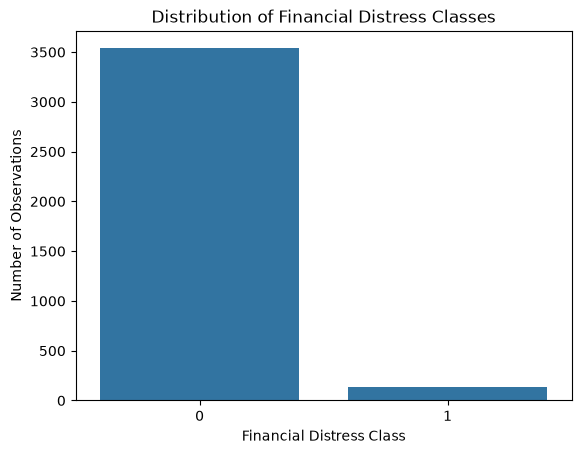

In [53]:
sns.countplot(data=df, x="Distress_Class")
plt.title("Distribution of Financial Distress Classes")
plt.xlabel("Financial Distress Class")
plt.ylabel("Number of Observations")
plt.show()

## 3. Data Understanding

The dataset contains financial and non-financial characteristics of companies observed across multiple time periods. The dataset contains 3,672 observations and 86 columns.

The variables include a company identifier, time period, the original Financial Distress score, and 83 predictor variables (x1–x83).

The target variable will be transformed into a binary classification variable, where observations with a Financial Distress score less than or equal to -0.50 are classified as financially distressed, while observations above -0.50 are classified as healthy.

In [54]:
df.duplicated().sum()

np.int64(0)

No duplicate records were identified in the dataset.

In [55]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

No missing values were identified across the dataset.

22

In [56]:
np.isinf(df.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [57]:
df["Company"].nunique()

422

In [58]:
df["Time"].value_counts().sort_index()

Time
1     242
2     271
3     277
4     274
5     266
6     263
7     257
8     245
9     245
10    249
11    259
12    270
13    274
14    280
Name: count, dtype: int64

In [59]:
df["x80"].nunique()

37

In [60]:
df["x80"].unique()

array([22, 29, 25, 12, 23,  9, 28, 14, 11, 18, 26, 21,  3, 20, 15,  7, 24,
       19, 27,  1,  4, 17,  6,  8,  5,  2, 16, 13, 10, 30, 31, 32, 34, 35,
       36, 33, 37])

In [61]:
numerical_features = df.select_dtypes(include=["float64"]).columns.tolist()

numerical_features

['Financial Distress',
 'x1',
 'x2',
 'x3',
 'x4',
 'x5',
 'x6',
 'x7',
 'x8',
 'x9',
 'x10',
 'x11',
 'x12',
 'x13',
 'x14',
 'x15',
 'x16',
 'x17',
 'x18',
 'x19',
 'x20',
 'x21',
 'x22',
 'x23',
 'x24',
 'x25',
 'x26',
 'x27',
 'x28',
 'x29',
 'x30',
 'x31',
 'x32',
 'x33',
 'x34',
 'x35',
 'x36',
 'x37',
 'x38',
 'x39',
 'x40',
 'x41',
 'x42',
 'x43',
 'x44',
 'x45',
 'x46',
 'x47',
 'x48',
 'x49',
 'x50',
 'x51',
 'x52',
 'x53',
 'x54',
 'x55',
 'x56',
 'x57',
 'x58',
 'x59',
 'x60',
 'x61',
 'x62',
 'x63',
 'x64',
 'x65',
 'x66',
 'x67',
 'x68',
 'x69',
 'x70',
 'x71',
 'x72',
 'x73',
 'x74',
 'x75',
 'x76',
 'x77',
 'x78',
 'x79',
 'x81']

In [62]:
categorical_features = ["x80"]

categorical_features

['x80']

In [66]:
feature_columns = [
    col for col in df.columns
    if col not in ["Company", "Financial Distress", "Distress_Class"]
]

len(feature_columns)

84

In [67]:
feature_columns

['Time',
 'x1',
 'x2',
 'x3',
 'x4',
 'x5',
 'x6',
 'x7',
 'x8',
 'x9',
 'x10',
 'x11',
 'x12',
 'x13',
 'x14',
 'x15',
 'x16',
 'x17',
 'x18',
 'x19',
 'x20',
 'x21',
 'x22',
 'x23',
 'x24',
 'x25',
 'x26',
 'x27',
 'x28',
 'x29',
 'x30',
 'x31',
 'x32',
 'x33',
 'x34',
 'x35',
 'x36',
 'x37',
 'x38',
 'x39',
 'x40',
 'x41',
 'x42',
 'x43',
 'x44',
 'x45',
 'x46',
 'x47',
 'x48',
 'x49',
 'x50',
 'x51',
 'x52',
 'x53',
 'x54',
 'x55',
 'x56',
 'x57',
 'x58',
 'x59',
 'x60',
 'x61',
 'x62',
 'x63',
 'x64',
 'x65',
 'x66',
 'x67',
 'x68',
 'x69',
 'x70',
 'x71',
 'x72',
 'x73',
 'x74',
 'x75',
 'x76',
 'x77',
 'x78',
 'x79',
 'x80',
 'x81',
 'x82',
 'x83']

In [68]:
df[feature_columns].dtypes.value_counts()

float64    80
int64       4
Name: count, dtype: int64

In [69]:
model_df = df[feature_columns + ["Distress_Class"]].copy()

In [70]:
model_df.shape

(3672, 85)

In [71]:
model_df.head()

,Time,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x75,x76,x77,x78,x79,x80,x81,x82,x83,Distress_Class
0,1,1.2810,0.022934,0.87454,1.21640,0.060940,0.188270,0.52510,0.018854,0.182790,...,27.07,26.102,16.000,16.0,0.2,22,0.060390,30,49,0
1,2,1.2700,0.006454,0.82067,1.00490,-0.014080,0.181040,0.62288,0.006423,0.035991,...,31.31,30.194,17.000,16.0,0.4,22,0.010636,31,50,0
2,3,1.0529,-0.059379,0.92242,0.72926,0.020476,0.044865,0.43292,-0.081423,-0.765400,...,36.07,35.273,17.000,15.0,-0.2,22,-0.455970,32,51,0
3,4,1.1131,-0.015229,0.85888,0.80974,0.076037,0.091033,0.67546,-0.018807,-0.107910,...,39.80,38.377,17.167,16.0,5.6,22,-0.325390,33,52,1
4,1,1.0623,0.107020,0.81460,0.83593,0.199960,0.047800,0.74200,0.128030,0.577250,...,27.07,26.102,16.000,16.0,0.2,29,1.251000,7,27,0


In [72]:
df.groupby("Time")["Distress_Class"].agg(["count", "sum", "mean"])

,count,sum,mean
Time,,,
1,242,10,0.041322
2,271,17,0.062731
3,277,12,0.043321
4,274,8,0.029197
5,266,6,0.022556
6,263,9,0.034221
7,257,16,0.062257
8,245,9,0.036735
9,245,13,0.053061


In [73]:
df.groupby("x80")["Distress_Class"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)

,count,sum,mean
x80,,,
13,4,1,0.250000
12,79,14,0.177215
11,32,3,0.093750
27,47,4,0.085106
7,12,1,0.083333
1,14,1,0.071429
22,157,11,0.070064
20,104,7,0.067308
21,119,8,0.067227


In [74]:
df[["Financial Distress"] + [f"x{i}" for i in range(1, 84)]].isnull().sum().sum()

np.int64(0)

In [75]:
df[[f"x{i}" for i in range(1, 84)]].describe().T

,count,mean,std,min,25%,50%,75%,max
x1,3672.0,1.387820,1.452926,7.517000e-02,0.952145,1.183600,1.506475,51.95400
x2,3672.0,0.129706,0.120013,-2.580800e-01,0.048701,0.107530,0.188685,0.74941
x3,3672.0,0.615769,0.177904,1.613500e-02,0.501888,0.638690,0.749425,0.96790
x4,3672.0,0.868160,0.571952,5.350000e-07,0.552558,0.775245,1.039000,6.83560
x5,3672.0,0.154949,0.124904,-2.697900e-01,0.070001,0.131830,0.219570,0.85854
...,...,...,...,...,...,...,...,...
x79,3672.0,-2.664305,8.192663,-2.020000e+01,-7.000000,0.200000,2.100000,8.60000
x80,3672.0,19.714597,7.508588,1.000000e+00,14.000000,20.000000,26.000000,37.00000
x81,3672.0,1.100488,2.666733,-4.992200e-01,0.189912,0.594765,1.355050,128.40000
x82,3672.0,13.122277,9.465907,1.000000e+00,6.000000,11.000000,17.000000,49.00000


In [76]:
Q1 = df[[f"x{i}" for i in range(1, 84)]].quantile(0.25)
Q3 = df[[f"x{i}" for i in range(1, 84)]].quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    (df[[f"x{i}" for i in range(1, 84)]] < (Q1 - 1.5 * IQR)) |
    (df[[f"x{i}" for i in range(1, 84)]] > (Q3 + 1.5 * IQR))
).sum()

outlier_counts.sort_values(ascending=False).head(15)

x12    609
x27    603
x31    542
x59    538
x15    517
x74    497
x58    482
x42    441
x55    430
x43    405
x17    379
x54    374
x34    373
x44    368
x57    363
dtype: int64

In [77]:
class_summary = df["Distress_Class"].value_counts().rename_axis("Class").reset_index(name="Count")

class_summary["Percentage"] = (
    class_summary["Count"] / len(df) * 100
)

class_summary

,Class,Count,Percentage
0,0,3536,96.296296
1,1,136,3.703704


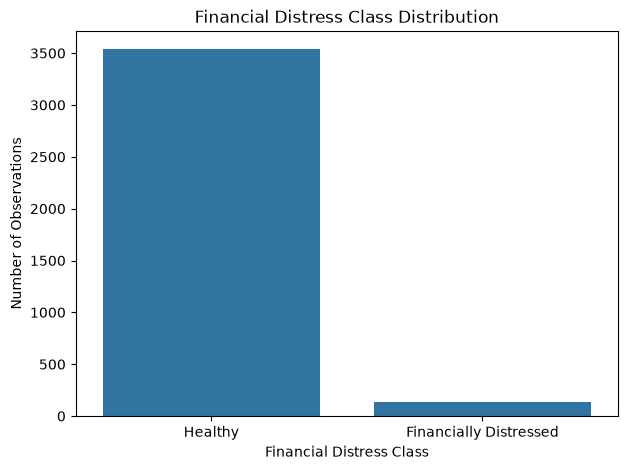

In [78]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Distress_Class")

plt.title("Financial Distress Class Distribution")
plt.xlabel("Financial Distress Class")
plt.ylabel("Number of Observations")

plt.xticks([0, 1], ["Healthy", "Financially Distressed"])

plt.show()

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of financial distress, identify patterns across time and categorical variables, and investigate relationships between the predictor variables and the target classification.

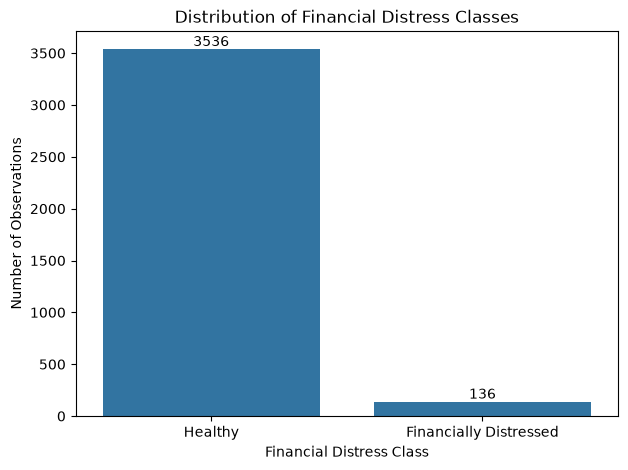

In [79]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="Distress_Class")

plt.title("Distribution of Financial Distress Classes")
plt.xlabel("Financial Distress Class")
plt.ylabel("Number of Observations")
plt.xticks([0, 1], ["Healthy", "Financially Distressed"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

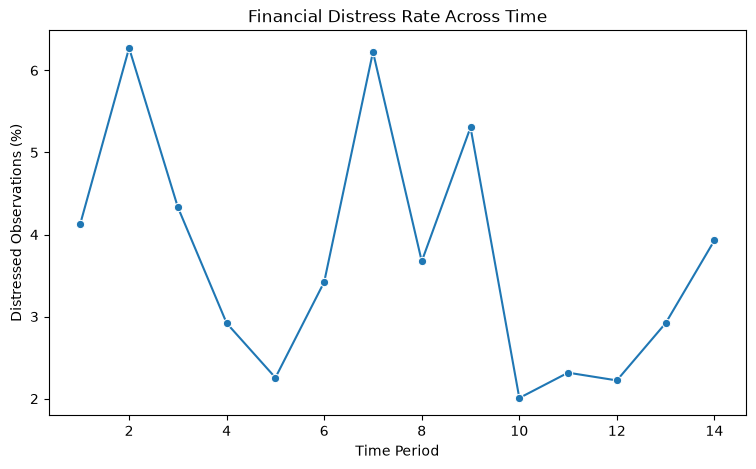

In [80]:
time_distress = (
    df.groupby("Time")["Distress_Class"]
    .mean()
    .reset_index()
)

time_distress["Distress_Rate"] = time_distress["Distress_Class"] * 100

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=time_distress,
    x="Time",
    y="Distress_Rate",
    marker="o"
)

plt.title("Financial Distress Rate Across Time")
plt.xlabel("Time Period")
plt.ylabel("Distressed Observations (%)")

plt.show()

In [81]:
x80_summary = (
    df.groupby("x80")["Distress_Class"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

x80_summary["Distress_Rate"] = x80_summary["mean"] * 100

x80_summary = x80_summary.sort_values(
    "Distress_Rate",
    ascending=False
)

x80_summary

,x80,count,sum,mean,Distress_Rate
12,13,4,1,0.250000,25.000000
11,12,79,14,0.177215,17.721519
10,11,32,3,0.093750,9.375000
26,27,47,4,0.085106,8.510638
6,7,12,1,0.083333,8.333333
0,1,14,1,0.071429,7.142857
21,22,157,11,0.070064,7.006369
19,20,104,7,0.067308,6.730769
20,21,119,8,0.067227,6.722689
30,31,18,1,0.055556,5.555556


In [82]:
x80_plot = x80_summary[x80_summary["count"] >= 30].copy()

x80_plot

,x80,count,sum,mean,Distress_Rate
11,12,79,14,0.177215,17.721519
10,11,32,3,0.093750,9.375000
26,27,47,4,0.085106,8.510638
21,22,157,11,0.070064,7.006369
19,20,104,7,0.067308,6.730769
20,21,119,8,0.067227,6.722689
13,14,236,12,0.050847,5.084746
25,26,274,13,0.047445,4.744526
18,19,169,8,0.047337,4.733728
17,18,245,11,0.044898,4.489796


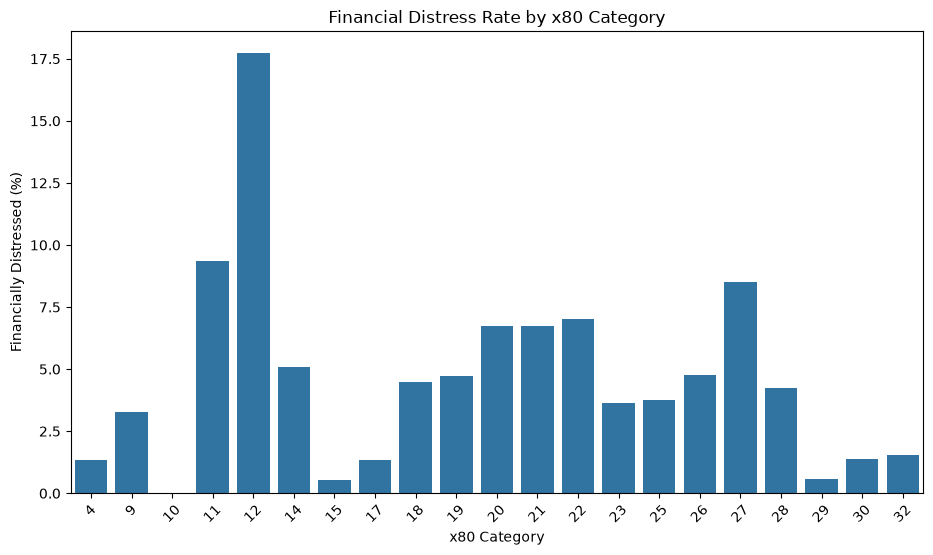

In [83]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=x80_plot,
    x="x80",
    y="Distress_Rate"
)

plt.title("Financial Distress Rate by x80 Category")
plt.xlabel("x80 Category")
plt.ylabel("Financially Distressed (%)")
plt.xticks(rotation=45)

plt.show()

In [84]:
numeric_for_correlation = [
    col for col in [f"x{i}" for i in range(1, 84)]
    if col != "x80"
]

correlations = (
    df[numeric_for_correlation + ["Distress_Class"]]
    .corr()["Distress_Class"]
    .drop("Distress_Class")
    .sort_values()
)

correlations.head(10)

x9    -0.269254
x2    -0.242083
x10   -0.234725
x5    -0.229287
x13   -0.207098
x55   -0.192320
x53   -0.190683
x23   -0.181492
x36   -0.180824
x60   -0.162371
Name: Distress_Class, dtype: float64

In [85]:
correlations.tail(10).sort_values(ascending=False)

x14    0.291381
x49    0.277275
x3     0.207098
x37    0.184847
x50    0.181490
x24    0.171165
x41    0.105527
x8     0.068213
x29    0.060343
x19    0.056897
Name: Distress_Class, dtype: float64

In [86]:
top_correlations = correlations.abs().sort_values(ascending=False).head(10)

top_correlations

x14    0.291381
x49    0.277275
x9     0.269254
x2     0.242083
x10    0.234725
x5     0.229287
x3     0.207098
x13    0.207098
x55    0.192320
x53    0.190683
Name: Distress_Class, dtype: float64

In [87]:
top_10_corr = correlations.loc[
    correlations.abs().sort_values(ascending=False).head(10).index
]

top_10_corr

x14    0.291381
x49    0.277275
x9    -0.269254
x2    -0.242083
x10   -0.234725
x5    -0.229287
x3     0.207098
x13   -0.207098
x55   -0.192320
x53   -0.190683
Name: Distress_Class, dtype: float64

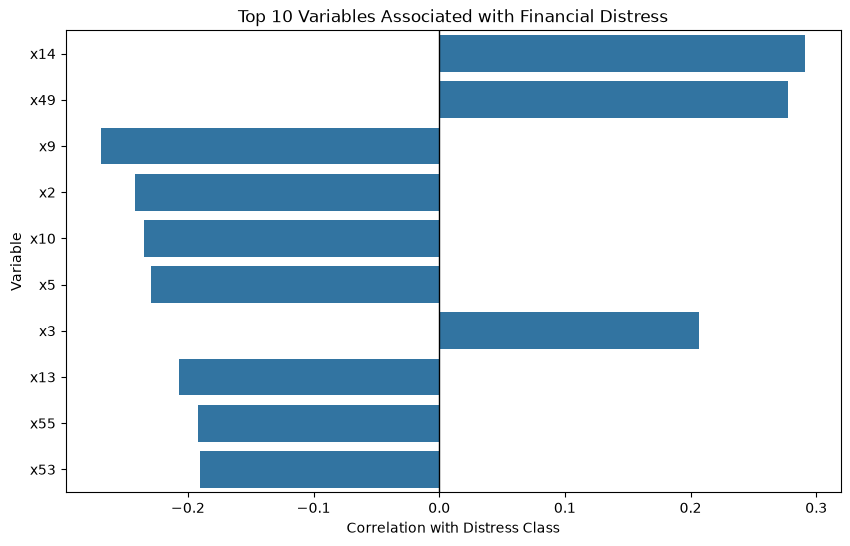

In [88]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_corr.values,
    y=top_10_corr.index
)

plt.title("Top 10 Variables Associated with Financial Distress")
plt.xlabel("Correlation with Distress Class")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=1)

plt.show()

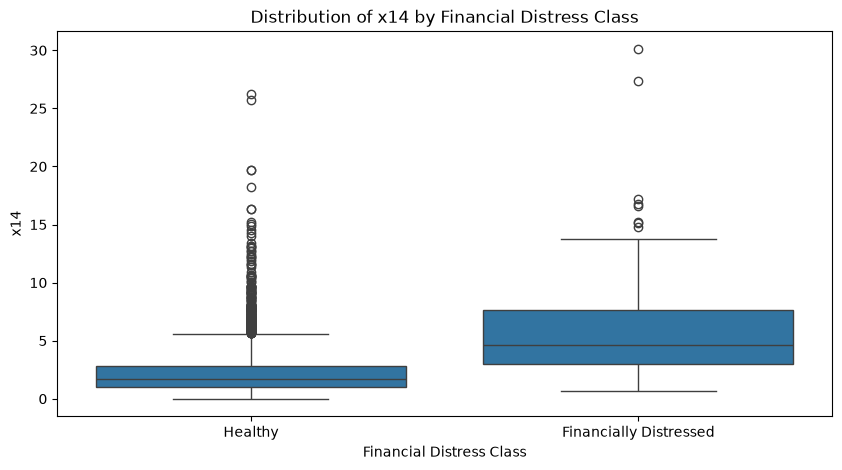

In [89]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Distress_Class",
    y="x14"
)

plt.title("Distribution of x14 by Financial Distress Class")
plt.xlabel("Financial Distress Class")
plt.ylabel("x14")
plt.xticks([0, 1], ["Healthy", "Financially Distressed"])

plt.show()

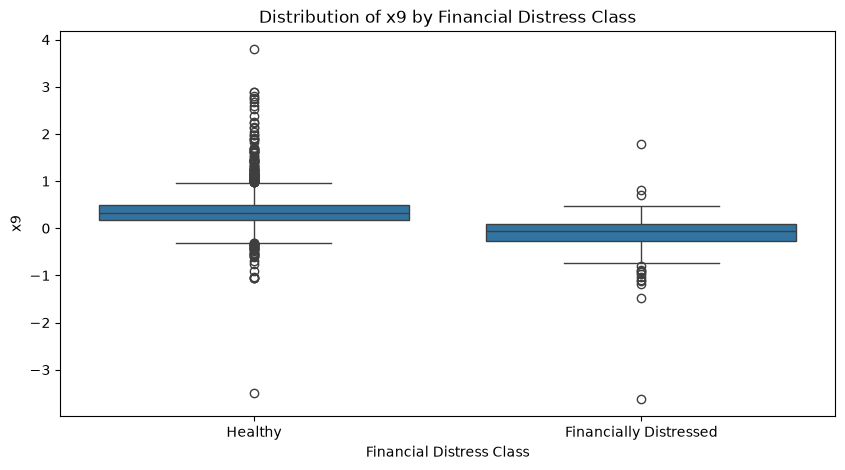

In [90]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Distress_Class",
    y="x9"
)

plt.title("Distribution of x9 by Financial Distress Class")
plt.xlabel("Financial Distress Class")
plt.ylabel("x9")
plt.xticks([0, 1], ["Healthy", "Financially Distressed"])

plt.show()

In [91]:
time_summary = (
    df.groupby("Time")["Distress_Class"]
    .agg(["count", "sum", "mean"])
)

time_summary["Distress_Rate"] = time_summary["mean"] * 100

time_summary

,count,sum,mean,Distress_Rate
Time,,,,
1,242,10,0.041322,4.132231
2,271,17,0.062731,6.273063
3,277,12,0.043321,4.332130
4,274,8,0.029197,2.919708
5,266,6,0.022556,2.255639
6,263,9,0.034221,3.422053
7,257,16,0.062257,6.225681
8,245,9,0.036735,3.673469
9,245,13,0.053061,5.306122


In [92]:
X = df.drop(columns=["Company", "Financial Distress", "Distress_Class"])
y = df["Distress_Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3672, 84)
y shape: (3672,)


In [93]:
categorical_features = ["x80"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical feature:")
print(categorical_features)

print("\nFirst 10 numerical features:")
print(numerical_features[:10])

Number of numerical features: 83
Number of categorical features: 1

Categorical feature:
['x80']

First 10 numerical features:
['Time', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']


In [94]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=df["Company"])
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2876, 84)
Testing set: (796, 84)


In [95]:
print("Training set class distribution:")
print(y_train.value_counts())
print()

print("Training set percentages:")
print(y_train.value_counts(normalize=True) * 100)
print()

print("Testing set class distribution:")
print(y_test.value_counts())
print()

print("Testing set percentages:")
print(y_test.value_counts(normalize=True) * 100)

Training set class distribution:
Distress_Class
0    2758
1     118
Name: count, dtype: int64

Training set percentages:
Distress_Class
0    95.897079
1     4.102921
Name: proportion, dtype: float64

Testing set class distribution:
Distress_Class
0    778
1     18
Name: count, dtype: int64

Testing set percentages:
Distress_Class
0    97.738693
1     2.261307
Name: proportion, dtype: float64


In [96]:
train_companies = set(df.iloc[train_idx]["Company"])
test_companies = set(df.iloc[test_idx]["Company"])

overlap = train_companies.intersection(test_companies)

print("Training companies:", len(train_companies))
print("Testing companies:", len(test_companies))
print("Companies appearing in both sets:", len(overlap))

Training companies: 337
Testing companies: 85
Companies appearing in both sets: 0


In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [98]:
from sklearn.pipeline import Pipeline

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [99]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [100]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [101]:
y_pred_lr = logistic_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_lr[:20])

First 20 predictions:
[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Performance
--------------------------------
Accuracy : 0.907035175879397
Precision: 0.15853658536585366
Recall   : 0.7222222222222222
F1 Score : 0.26


[[709  69]
 [  5  13]]


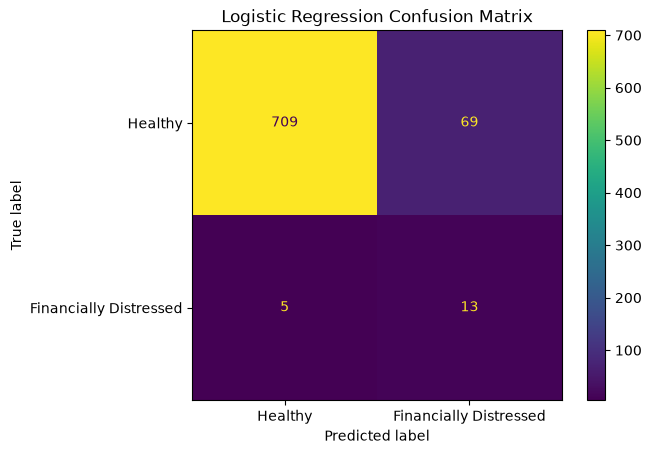

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Healthy", "Financially Distressed"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [104]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [105]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [106]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [107]:
y_pred_rf = random_forest_model.predict(X_test)

print("First 20 Random Forest predictions:")
print(y_pred_rf[:20])

First 20 Random Forest predictions:
[0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [108]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Performance
-------------------------
Accuracy : 0.9798994974874372
Precision: 0.5833333333333334
Recall   : 0.3888888888888889
F1 Score : 0.4666666666666667


[[773   5]
 [ 11   7]]


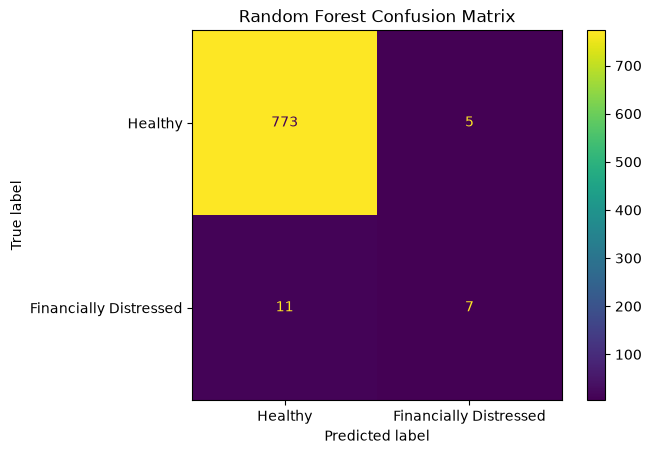

In [109]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Healthy", "Financially Distressed"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [110]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.907035,0.158537,0.722222,0.260000
1,Random Forest,0.979899,0.583333,0.388889,0.466667


In [111]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Healthy", "Financially Distressed"],
        zero_division=0
    )
)

Logistic Regression Classification Report
------------------------------------------
                        precision    recall  f1-score   support

               Healthy       0.99      0.91      0.95       778
Financially Distressed       0.16      0.72      0.26        18

              accuracy                           0.91       796
             macro avg       0.58      0.82      0.61       796
          weighted avg       0.97      0.91      0.93       796



In [112]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = logistic_model.named_steps["classifier"].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient
0,num__Time,2.398198,2.398198
106,cat__x80_24,-1.936137,1.936137
100,cat__x80_18,1.745538,1.745538
36,num__x36,-1.738419,1.738419
33,num__x33,-1.671118,1.671118
44,num__x44,-1.593602,1.593602
7,num__x7,-1.591839,1.591839
94,cat__x80_12,1.394280,1.394280
10,num__x10,-1.323507,1.323507
104,cat__x80_22,-1.316015,1.316015


In [113]:
print("Top variables pushing toward Financial Distress:")
print(
    coefficient_df
    .sort_values("Coefficient", ascending=False)
    .head(10)[["Feature", "Coefficient"]]
)

print("\nTop variables pushing toward Healthy:")
print(
    coefficient_df
    .sort_values("Coefficient", ascending=True)
    .head(10)[["Feature", "Coefficient"]]
)

Top variables pushing toward Financial Distress:
         Feature  Coefficient
0      num__Time     2.398198
100  cat__x80_18     1.745538
94   cat__x80_12     1.394280
48      num__x48     1.287358
95   cat__x80_13     1.148585
96   cat__x80_14     0.819550
107  cat__x80_25     0.721144
108  cat__x80_26     0.689139
24      num__x24     0.650018
8        num__x8     0.630528

Top variables pushing toward Healthy:
         Feature  Coefficient
106  cat__x80_24    -1.936137
36      num__x36    -1.738419
33      num__x33    -1.671118
44      num__x44    -1.593602
7        num__x7    -1.591839
10      num__x10    -1.323507
104  cat__x80_22    -1.316015
54      num__x54    -1.160731
92   cat__x80_10    -1.093562
5        num__x5    -0.945607


In [114]:
X_no_time = X.drop(columns=["Time"])

print("Original X shape:", X.shape)
print("X without Time:", X_no_time.shape)

Original X shape: (3672, 84)
X without Time: (3672, 83)


In [115]:
X_no_time_train = X_no_time.iloc[train_idx]
X_no_time_test = X_no_time.iloc[test_idx]

print("Training set without Time:", X_no_time_train.shape)
print("Testing set without Time:", X_no_time_test.shape)

Training set without Time: (2876, 83)
Testing set without Time: (796, 83)


In [116]:
numerical_features_no_time = [
    col for col in X_no_time.columns
    if col != "x80"
]

categorical_features_no_time = ["x80"]

print("Numerical features:", len(numerical_features_no_time))
print("Categorical features:", len(categorical_features_no_time))

Numerical features: 82
Categorical features: 1


In [117]:
logistic_preprocessor_no_time = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_no_time),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_no_time)
    ]
)

logistic_model_no_time = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor_no_time),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model_no_time

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [118]:
logistic_model_no_time.fit(
    X_no_time_train,
    y_train
)

print("Logistic Regression without Time trained successfully.")

Logistic Regression without Time trained successfully.


In [119]:
y_pred_lr_no_time = logistic_model_no_time.predict(X_no_time_test)

print("First 20 predictions without Time:")
print(y_pred_lr_no_time[:20])

First 20 predictions without Time:
[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [120]:
accuracy_lr_no_time = accuracy_score(y_test, y_pred_lr_no_time)
precision_lr_no_time = precision_score(
    y_test, y_pred_lr_no_time, zero_division=0
)
recall_lr_no_time = recall_score(
    y_test, y_pred_lr_no_time, zero_division=0
)
f1_lr_no_time = f1_score(
    y_test, y_pred_lr_no_time, zero_division=0
)

print("Logistic Regression Without Time")
print("--------------------------------")
print("Accuracy :", accuracy_lr_no_time)
print("Precision:", precision_lr_no_time)
print("Recall   :", recall_lr_no_time)
print("F1 Score :", f1_lr_no_time)

Logistic Regression Without Time
--------------------------------
Accuracy : 0.9095477386934674
Precision: 0.1625
Recall   : 0.7222222222222222
F1 Score : 0.2653061224489796


[[711  67]
 [  5  13]]


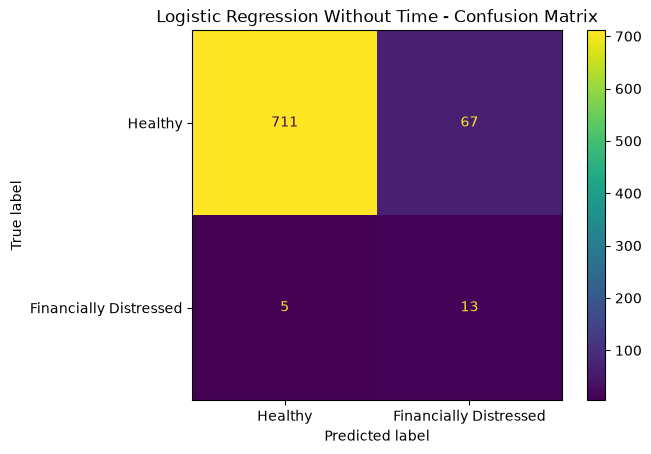

In [121]:
cm_lr_no_time = confusion_matrix(
    y_test,
    y_pred_lr_no_time
)

print(cm_lr_no_time)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_no_time,
    display_labels=["Healthy", "Financially Distressed"]
)

disp.plot()
plt.title("Logistic Regression Without Time - Confusion Matrix")
plt.show()

In [122]:
final_feature_names = (
    logistic_model_no_time
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

final_coefficients = (
    logistic_model_no_time
    .named_steps["classifier"]
    .coef_[0]
)

final_coefficient_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient": final_coefficients
})

final_coefficient_df["Absolute_Coefficient"] = (
    final_coefficient_df["Coefficient"].abs()
)

final_coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient
105,cat__x80_24,-1.843310,1.843310
35,num__x36,-1.714162,1.714162
32,num__x33,-1.666486,1.666486
99,cat__x80_18,1.656192,1.656192
43,num__x44,-1.566062,1.566062
6,num__x7,-1.565668,1.565668
103,cat__x80_22,-1.380350,1.380350
93,cat__x80_12,1.344199,1.344199
9,num__x10,-1.328801,1.328801
47,num__x48,1.228887,1.228887


In [123]:
numerical_coefficient_df = final_coefficient_df[
    final_coefficient_df["Feature"].str.startswith("num__")
].copy()

numerical_coefficient_df["Original_Feature"] = (
    numerical_coefficient_df["Feature"]
    .str.replace("num__", "", regex=False)
)

numerical_coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute_Coefficient,Original_Feature
35,num__x36,-1.714162,1.714162,x36
32,num__x33,-1.666486,1.666486,x33
43,num__x44,-1.566062,1.566062,x44
6,num__x7,-1.565668,1.565668,x7
9,num__x10,-1.328801,1.328801,x10
47,num__x48,1.228887,1.228887,x48
53,num__x54,-1.183545,1.183545,x54
4,num__x5,-0.931783,0.931783,x5
25,num__x26,-0.858959,0.858959,x26
24,num__x25,-0.779932,0.779932,x25


In [124]:
selected_features = ["x36", "x33", "x44", "x7", "x10"]

X_reduced = df[selected_features]

print("Selected features:")
print(selected_features)

print("\nReduced dataset shape:")
print(X_reduced.shape)

Selected features:
['x36', 'x33', 'x44', 'x7', 'x10']

Reduced dataset shape:
(3672, 5)


In [125]:
X_reduced_train = X_reduced.iloc[train_idx]
X_reduced_test = X_reduced.iloc[test_idx]

print("Training set shape:", X_reduced_train.shape)
print("Test set shape:", X_reduced_test.shape)

Training set shape: (2876, 5)
Test set shape: (796, 5)


In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

reduced_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Reduced Logistic Regression model created successfully.")

Reduced Logistic Regression model created successfully.


In [127]:
reduced_model.fit(X_reduced_train, y_train)

print("Reduced Logistic Regression model trained successfully.")

Reduced Logistic Regression model trained successfully.


In [128]:
y_pred_reduced = reduced_model.predict(X_reduced_test)

print("First 20 predictions:")
print(y_pred_reduced[:20])

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1]


In [129]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
precision_reduced = precision_score(y_test, y_pred_reduced)
recall_reduced = recall_score(y_test, y_pred_reduced)
f1_reduced = f1_score(y_test, y_pred_reduced)

print("Reduced Logistic Regression Performance")
print("----------------------------------------")
print(f"Accuracy : {accuracy_reduced:.4f}")
print(f"Precision: {precision_reduced:.4f}")
print(f"Recall   : {recall_reduced:.4f}")
print(f"F1 Score : {f1_reduced:.4f}")

Reduced Logistic Regression Performance
----------------------------------------
Accuracy : 0.8631
Precision: 0.1301
Recall   : 0.8889
F1 Score : 0.2270


Confusion Matrix:
[[671 107]
 [  2  16]]


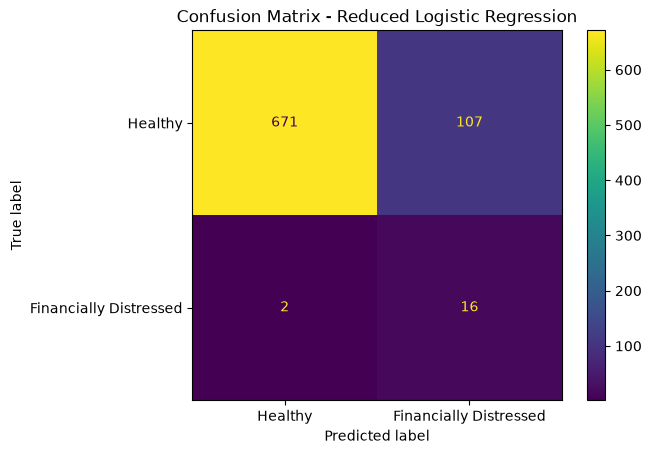

In [130]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_reduced = confusion_matrix(y_test, y_pred_reduced)

print("Confusion Matrix:")
print(cm_reduced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reduced,
    display_labels=["Healthy", "Financially Distressed"]
)

disp.plot()
plt.title("Confusion Matrix - Reduced Logistic Regression")
plt.show()

In [131]:
from sklearn.metrics import classification_report

print("Classification Report - Reduced Logistic Regression")
print(classification_report(
    y_test,
    y_pred_reduced,
    target_names=["Healthy", "Financially Distressed"]
))

Classification Report - Reduced Logistic Regression
                        precision    recall  f1-score   support

               Healthy       1.00      0.86      0.92       778
Financially Distressed       0.13      0.89      0.23        18

              accuracy                           0.86       796
             macro avg       0.56      0.88      0.58       796
          weighted avg       0.98      0.86      0.91       796



In [132]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Reduced Logistic Regression"
    ],
    "Accuracy": [
        0.9070,
        0.9799,
        accuracy_reduced
    ],
    "Precision": [
        0.1625,
        0.5833,
        precision_reduced
    ],
    "Recall": [
        0.7222,
        0.3889,
        recall_reduced
    ],
    "F1 Score": [
        0.2600,
        0.4667,
        f1_reduced
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.907000,0.162500,0.722200,0.26000
1,Random Forest,0.979900,0.583300,0.388900,0.46670
2,Reduced Logistic Regression,0.863065,0.130081,0.888889,0.22695


In [133]:
reduced_coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": reduced_model.named_steps["classifier"].coef_[0]
})

reduced_coefficients["Absolute_Coefficient"] = (
    reduced_coefficients["Coefficient"].abs()
)

reduced_coefficients = reduced_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

reduced_coefficients

,Feature,Coefficient,Absolute_Coefficient
4,x10,-2.517405,2.517405
2,x44,-1.677187,1.677187
0,x36,-1.001839,1.001839
3,x7,-0.623541,0.623541
1,x33,-0.225216,0.225216


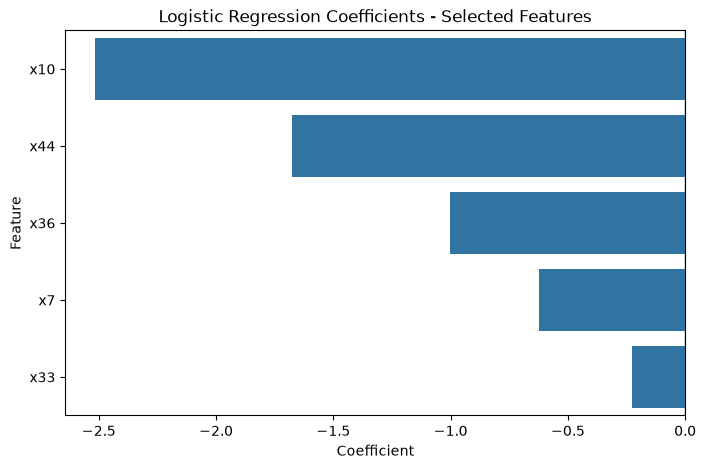

In [134]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=reduced_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(0, linewidth=1)
plt.title("Logistic Regression Coefficients - Selected Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [135]:
y_prob_reduced = reduced_model.predict_proba(X_reduced_test)[:, 1]

print("First 10 distress probabilities:")
print(y_prob_reduced[:10])

First 10 distress probabilities:
[0.71309755 0.71644299 0.89659191 0.8827283  0.59255169 0.63879415
 0.70870382 0.65279389 0.58687067 0.59136925]


In [136]:
print("Final model:", reduced_model)
print("\nFeatures used by the final model:")
print(selected_features)

print("\nNumber of input features:", len(selected_features))

Final model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Features used by the final model:
['x36', 'x33', 'x44', 'x7', 'x10']

Number of input features: 5


In [137]:
import joblib

joblib.dump(reduced_model, "model.pkl")

print("Final model saved successfully as model.pkl")

Final model saved successfully as model.pkl


In [138]:
import os

print("model.pkl exists:", os.path.exists("model.pkl"))
print("Current notebook folder:", os.getcwd())

model.pkl exists: True
Current notebook folder: /Users/aakash


In [139]:
import shutil
import os

source = "/Users/aakash/model.pkl"
destination = "/Users/aakash/Documents/MLBA Assignment/Financial Distress Project/model.pkl"

shutil.copy(source, destination)

print("Model copied successfully.")
print("Model exists in project folder:", os.path.exists(destination))

Model copied successfully.
Model exists in project folder: True


In [140]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.58.0
